# Portada

## Tema
Análisis exploratorio y predicción de satisfacción de usuarios en una plataforma digital educativa mediante Python y Machine Learning básico

## Estudiante
Sonia Guama

## Módulo
MTDI202: Big Data, Analytics & Data Scientist

## Docente
Ing. Carlos Wladimir Carrillo Villavicencio MSc. TIC.

## Fecha
Junio 2026

# Indice

1. [Portada](#scrollTo-d-DVp6W6Xgt3)
3. [Carga de Librerías](#scrollTo-p-P0YjzwaWhQ)
4. [Carga y lectura del dataset](#scrollTo-RGEi3CzDa7kz)
5. [Descripción del dataset](#scrollTo-pJbaVTgXeB03)
6. [Revisión inicial de estructura](#scrollTo-E6ptJ1E0ejzX)
7. [Limpieza y preparación](#scrollTo-PiWe6RLBhivo)
8. [Análisis exploratorio de datos](#scrollTo-NkHXK5GRjUFf)
9. [Visualización de datos](#scrollTo-m6DJ46CzjW6O)
10. [Machine Learning básico](#scrollTo-e4I2KI5ejZ-4)
11. [Evaluación del modelo](#scrollTo-rmtXGY0ZjdfV)
12. [Resultados y conclusiones](#scrollTo-PbtPSu2tpNxQ)


# Carga de Librerías

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")

# Carga y lectura del dataset

In [7]:
content_data = pd.read_csv("/content/digital_service_experience_dataset.csv")

# Descripción del dataset


El dataset utilizado en este notebook se denomina `digital_service_experience_dataset.csv` y fue construido de forma sintética con fines académicos. Su propósito es representar la experiencia de usuarios en una plataforma digital educativa, considerando variables demográficas, tecnológicas, operativas y de percepción.

Cada registro representa una interacción o evaluación realizada por un usuario sobre el uso de la plataforma. El conjunto de datos permite analizar factores asociados con la satisfacción del usuario, tales como la calidad de internet, el tipo de dispositivo utilizado, la capacitación recibida, los errores reportados, los tickets de soporte, el tiempo de respuesta del soporte, la usabilidad percibida y el puntaje de recomendación.

El dataset contiene variables numéricas, categóricas y una variable de fecha, lo que permite aplicar análisis descriptivo, análisis exploratorio, visualización de datos y modelado supervisado básico. La variable objetivo seleccionada para el modelo de Machine Learning es `satisfied`, la cual permite clasificar si un usuario presenta una experiencia satisfactoria (`1`) o no satisfactoria (`0`) dentro de la plataforma digital educativa.

| Campo | Descripción |
|---|---|
| Nombre del dataset | `digital_service_experience_dataset.csv` |
| Fuente u origen de los datos | Dataset sintético generado con fines académicos |
| Formato del archivo | CSV |
| Número de registros | 1.515 registros iniciales |
| Número de columnas | 22 columnas iniciales |
| Periodo de análisis | Enero 2025 a junio 2026 |
| Área o dominio del dataset | Educación digital / Transformación digital / Experiencia de usuario |
| Nivel de sensibilidad de datos | Datos sintéticos, sin información personal, laboral, sensible o confidencial |


# Revisión inicial de estructura

In [8]:
content_data.head()

,user_id,interaction_date,age,gender,city,user_type,device_type,internet_quality,sessions_per_week,avg_session_minutes,...,support_tickets,response_time_hours,platform_errors,training_received,support_channel,platform_module,perceived_usability,recommendation_score,satisfaction_level,satisfied
0,USR00386,2025-04-26,24,Femenino,Ibarra,Estudiante,Computador de escritorio,Media,6,34.9,...,0,1.7,2,Sí,Chat,Pagos,4.3,6,Baja,0
1,USR01436,2025-11-28,23,Masculino,Ambato,Estudiante,Laptop,Alta,2,41.2,...,0,2.2,2,No,Autoservicio,Evaluaciones,3.5,4,Media,0
2,USR00204,2025-05-14,33,Masculino,Guayaquil,Estudiante,Laptop,Media,5,55.6,...,0,2.9,1,Sí,Autoservicio,Biblioteca digital,4.0,8,Media,0
3,USR01396,2025-06-24,27,Masculino,Manta,Estudiante,Móvil,Media,4,30.2,...,2,6.9,2,Sí,Teléfono,Evaluaciones,3.2,5,Media,0
4,USR01229,2025-04-28,20,Masculino,Quito,Estudiante,Móvil,Media,8,18.7,...,3,5.2,3,No,Autoservicio,Aula virtual,2.6,2,Baja,0


In [9]:
content_data.tail()

,user_id,interaction_date,age,gender,city,user_type,device_type,internet_quality,sessions_per_week,avg_session_minutes,...,support_tickets,response_time_hours,platform_errors,training_received,support_channel,platform_module,perceived_usability,recommendation_score,satisfaction_level,satisfied
1510,USR00860,2026-03-20,34,Masculino,Cuenca,Estudiante,Laptop,Media,4,16.2,...,3,9.0,3,No,Chat,Pagos,2.1,3,Baja,0
1511,USR00512,2025-03-12,30,Femenino,Quito,Estudiante,Laptop,Media,5,57.7,...,0,2.6,3,Sí,Chat,Soporte académico,3.5,4,Baja,0
1512,USR00618,2025-11-10,30,Masculino,Manta,Estudiante,Móvil,Media,7,28.8,...,1,3.8,2,Sí,Teléfono,Evaluaciones,3.7,8,Media,0
1513,USR01332,2025-12-21,40,Femenino,Loja,Estudiante,Computador de escritorio,Media,6,29.7,...,2,3.9,0,No,Chat,Evaluaciones,2.3,7,Baja,0
1514,USR01084,2025-07-16,48,Masculino,Quito,Estudiante,Laptop,Alta,4,58.0,...,2,3.6,3,Sí,Correo,Evaluaciones,3.3,5,Baja,0


In [60]:
content_data.shape

(1515, 22)

In [83]:
content_data.columns

Index(['user_id', 'interaction_date', 'age', 'gender', 'city', 'user_type',
       'device_type', 'internet_quality', 'sessions_per_week',
       'avg_session_minutes', 'completed_activities', 'pending_activities',
       'support_tickets', 'response_time_hours', 'platform_errors',
       'training_received', 'support_channel', 'platform_module',
       'perceived_usability', 'recommendation_score', 'satisfaction_level',
       'satisfied'],
      dtype='object')

In [84]:
content_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1515 non-null   object 
 1   interaction_date      1515 non-null   object 
 2   age                   1515 non-null   int64  
 3   gender                1515 non-null   object 
 4   city                  1515 non-null   object 
 5   user_type             1515 non-null   object 
 6   device_type           1515 non-null   object 
 7   internet_quality      1470 non-null   object 
 8   sessions_per_week     1515 non-null   int64  
 9   avg_session_minutes   1515 non-null   float64
 10  completed_activities  1515 non-null   int64  
 11  pending_activities    1515 non-null   int64  
 12  support_tickets       1515 non-null   int64  
 13  response_time_hours   1480 non-null   float64
 14  platform_errors       1515 non-null   int64  
 15  training_received    

In [13]:
content_data.dtypes

,0
user_id,object
interaction_date,object
age,int64
gender,object
city,object
user_type,object
device_type,object
internet_quality,object
sessions_per_week,int64
avg_session_minutes,float64


In [85]:
content_data.describe()

,age,sessions_per_week,avg_session_minutes,completed_activities,pending_activities,support_tickets,response_time_hours,platform_errors,perceived_usability,recommendation_score,satisfied
count,1515.000000,1515.000000,1515.000000,1515.000000,1515.000000,1515.000000,1480.000000,1515.000000,1515.000000,1515.000000,1515.000000
mean,30.700990,5.378878,40.696766,16.867327,6.607261,1.534653,6.172703,2.343894,3.164884,5.013201,0.170957
std,8.539811,2.378143,18.997373,5.698984,3.680191,1.443093,6.023069,1.964653,0.949641,2.181606,0.376596
min,17.000000,1.000000,5.000000,1.000000,0.000000,0.000000,0.500000,0.000000,1.000000,0.000000,0.000000
25%,24.000000,4.000000,28.450000,13.000000,4.000000,0.000000,3.175000,1.000000,2.500000,4.000000,0.000000
50%,31.000000,5.000000,39.300000,17.000000,6.000000,1.000000,4.900000,2.000000,3.200000,5.000000,0.000000
75%,36.000000,7.000000,51.000000,21.000000,9.000000,2.000000,7.400000,4.000000,3.900000,7.000000,0.000000
max,57.000000,12.000000,170.900000,38.000000,21.000000,8.000000,78.200000,11.000000,5.000000,10.000000,1.000000


In [15]:
content_data.describe(include="object")

,user_id,interaction_date,gender,city,user_type,device_type,internet_quality,training_received,support_channel,platform_module,satisfaction_level
count,1515,1515,1515,1515,1515,1515,1470,1485,1515,1515,1515
unique,1500,512,3,8,3,4,3,2,4,6,3
top,USR00986,2025-03-27,Femenino,Quito,Estudiante,Laptop,Media,Sí,Chat,Aula virtual,Baja
freq,2,9,781,464,1185,680,719,860,623,458,664


In [16]:
content_data.isnull().sum()

,0
user_id,0
interaction_date,0
age,0
gender,0
city,0
user_type,0
device_type,0
internet_quality,45
sessions_per_week,0
avg_session_minutes,0


In [17]:
content_data.duplicated().sum()

np.int64(15)

# Limpieza y preparación

In [86]:
content_data_clean = content_data.copy()

In [87]:
content_data_clean = content_data_clean.drop_duplicates()
content_data_clean.shape

(1500, 22)

In [88]:
# Validación de duplicados después de la limpieza
content_data_clean.duplicated().sum()

np.int64(0)

In [89]:
content_data_clean["interaction_date"] = pd.to_datetime(content_data_clean["interaction_date"], errors="coerce")
content_data_clean["interaction_date"].dtype

dtype('<M8[ns]')

In [90]:
content_data_clean["year"] = content_data_clean["interaction_date"].dt.year
content_data_clean["month"] = content_data_clean["interaction_date"].dt.month
content_data_clean["year_month"] = content_data_clean["interaction_date"].dt.to_period("M").astype(str)

In [91]:
content_data_clean.isnull().sum()

,0
user_id,0
interaction_date,0
age,0
gender,0
city,0
user_type,0
device_type,0
internet_quality,45
sessions_per_week,0
avg_session_minutes,0


In [92]:
for col in ["internet_quality", "training_received"]:
    moda = content_data_clean[col].mode()[0]
    content_data_clean[col] = content_data_clean[col].fillna(moda)

In [93]:
content_data_clean["response_time_hours"] = content_data_clean["response_time_hours"].fillna(
    content_data_clean["response_time_hours"].median()
)

In [94]:
content_data_clean.isnull().sum()

,0
user_id,0
interaction_date,0
age,0
gender,0
city,0
user_type,0
device_type,0
internet_quality,0
sessions_per_week,0
avg_session_minutes,0


# Análisis exploratorio de datos

In [95]:
content_data_clean["satisfied"].value_counts()

,count
satisfied,
0,1241
1,259


In [96]:
content_data_clean["satisfaction_level"].value_counts()

,count
satisfaction_level,
Baja,653
Media,588
Alta,259


In [97]:
content_data_clean.nunique().sort_values(ascending=False)

,0
user_id,1500
avg_session_minutes,584
interaction_date,512
response_time_hours,194
age,41
perceived_usability,41
completed_activities,35
pending_activities,21
year_month,18
platform_errors,12


In [98]:
content_data_clean.groupby("user_type")["satisfied"].mean().sort_values(ascending=False)

,satisfied
user_type,
Administrativo,0.228571
Docente,0.170404
Estudiante,0.168089


In [99]:
content_data_clean.groupby("training_received")["satisfied"].mean()

,satisfied
training_received,
No,0.025932
Sí,0.275198


In [100]:
content_data_clean.groupby("internet_quality")["satisfied"].mean().sort_values(ascending=False)

,satisfied
internet_quality,
Alta,0.288660
Media,0.153034
Baja,0.011673


In [101]:
content_data_clean.groupby("satisfied").agg({
    "perceived_usability": "mean",
    "recommendation_score": "mean",
    "platform_errors": "mean",
    "support_tickets": "mean",
    "response_time_hours": "mean",
    "sessions_per_week": "mean",
    "completed_activities": "mean"
})

,perceived_usability,recommendation_score,platform_errors,support_tickets,response_time_hours,sessions_per_week,completed_activities
satisfied,,,,,,,
0,2.964786,4.573731,2.543110,1.605963,6.265189,5.348912,16.469782
1,4.128185,7.142857,1.397683,1.166023,5.581081,5.501931,18.810811


In [102]:
pd.crosstab(content_data_clean["internet_quality"], content_data_clean["satisfied"], normalize="index")

satisfied,0,1
internet_quality,,
Alta,0.711340,0.288660
Baja,0.988327,0.011673
Media,0.846966,0.153034


In [103]:
content_data_clean.query("platform_errors >= 5 and response_time_hours > 24").head()

,user_id,interaction_date,age,gender,city,user_type,device_type,internet_quality,sessions_per_week,avg_session_minutes,...,training_received,support_channel,platform_module,perceived_usability,recommendation_score,satisfaction_level,satisfied,year,month,year_month
63,USR00919,2025-12-11,32,Masculino,Ibarra,Estudiante,Computador de escritorio,Baja,4,64.6,...,No,Correo,Inscripciones,1.0,2,Baja,0,2025,12,2025-12
1311,USR01227,2025-08-10,31,Femenino,Ibarra,Estudiante,Móvil,Media,6,25.8,...,No,Chat,Biblioteca digital,3.0,5,Media,0,2025,8,2025-08


# Visualización de datos

Distribución de satisfacción

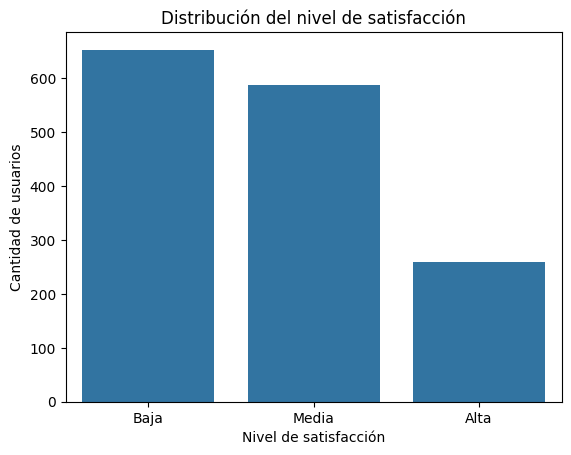

In [106]:
sns.countplot(data=content_data_clean, x="satisfaction_level")
plt.title("Distribución del nivel de satisfacción")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Cantidad de usuarios")
plt.show()

Satisfacción por calidad de internet

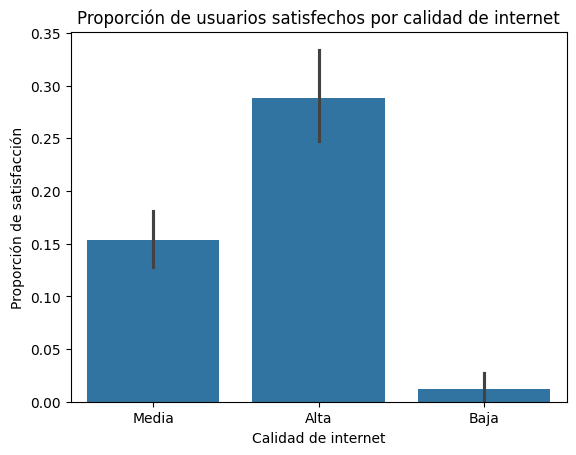

In [107]:
sns.barplot(data=content_data_clean, x="internet_quality", y="satisfied")
plt.title("Proporción de usuarios satisfechos por calidad de internet")
plt.xlabel("Calidad de internet")
plt.ylabel("Proporción de satisfacción")
plt.show()

Usabilidad percibida vs satisfacción

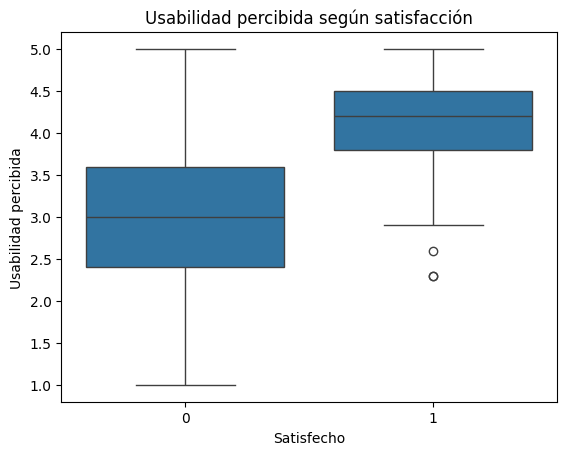

In [108]:
sns.boxplot(data=content_data_clean, x="satisfied", y="perceived_usability")
plt.title("Usabilidad percibida según satisfacción")
plt.xlabel("Satisfecho")
plt.ylabel("Usabilidad percibida")
plt.show()

Errores de plataforma vs satisfacción

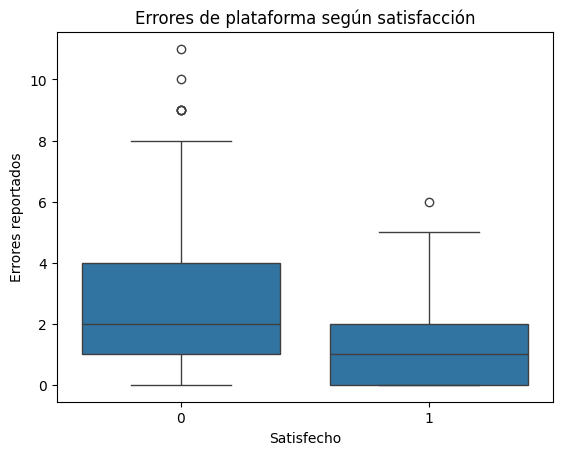

In [109]:
sns.boxplot(data=content_data_clean, x="satisfied", y="platform_errors")
plt.title("Errores de plataforma según satisfacción")
plt.xlabel("Satisfecho")
plt.ylabel("Errores reportados")
plt.show()

Tendencia temporal

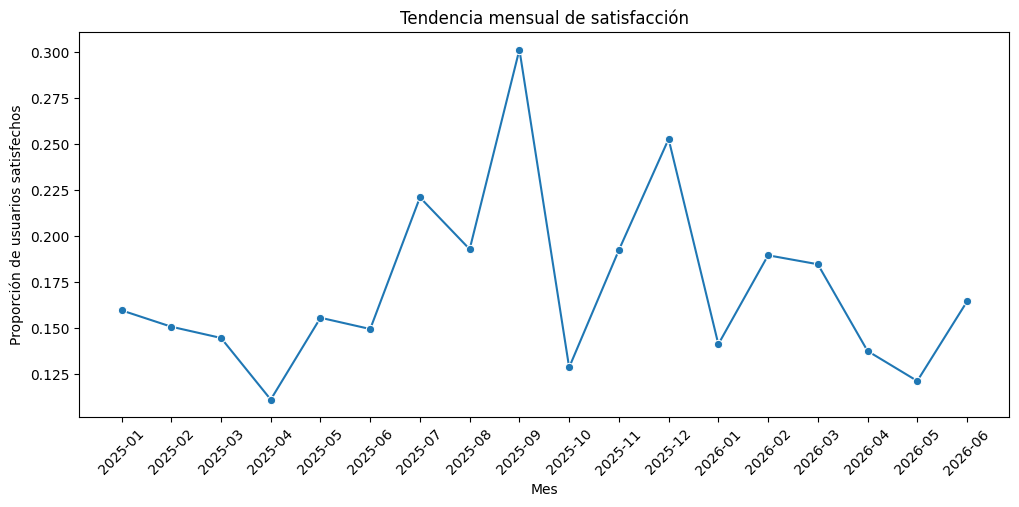

In [110]:
satisfaccion_mensual = content_data_clean.groupby("year_month")["satisfied"].mean().reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=satisfaccion_mensual, x="year_month", y="satisfied", marker="o")
plt.title("Tendencia mensual de satisfacción")
plt.xlabel("Mes")
plt.ylabel("Proporción de usuarios satisfechos")
plt.xticks(rotation=45)
plt.show()

Mapa de correlación

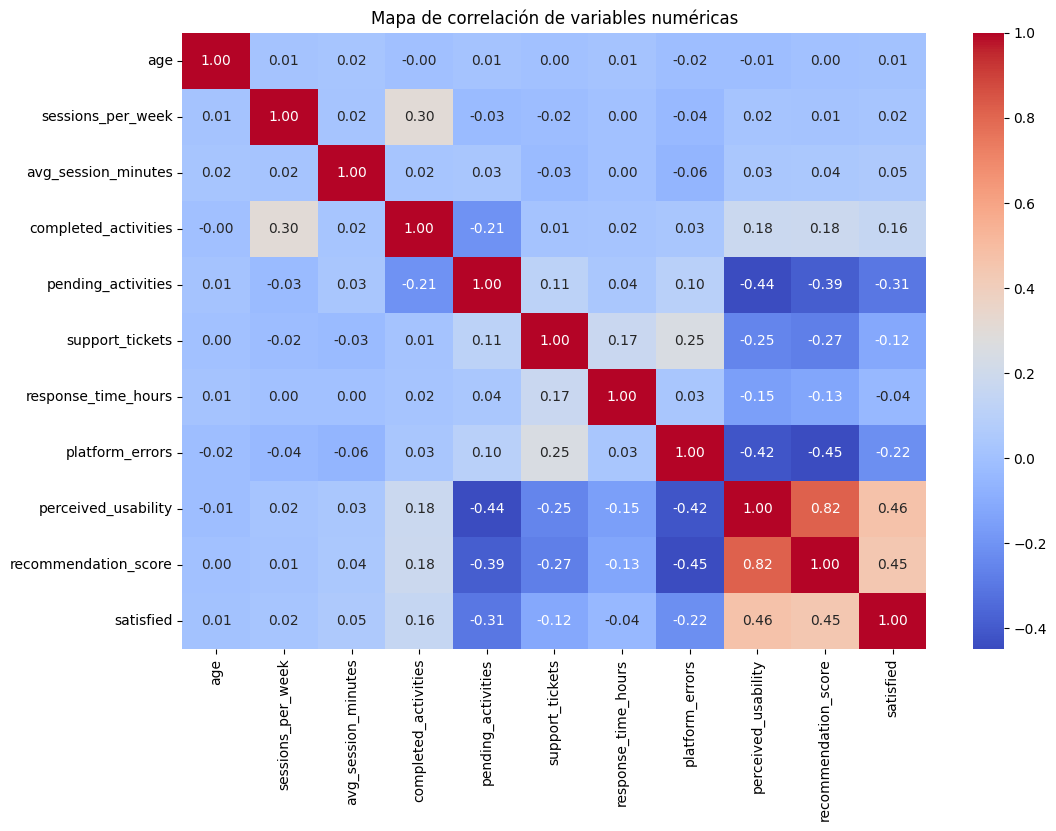

In [111]:
numeric_cols = content_data_clean.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(12,8))
sns.heatmap(content_data_clean[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de correlación de variables numéricas")
plt.show()

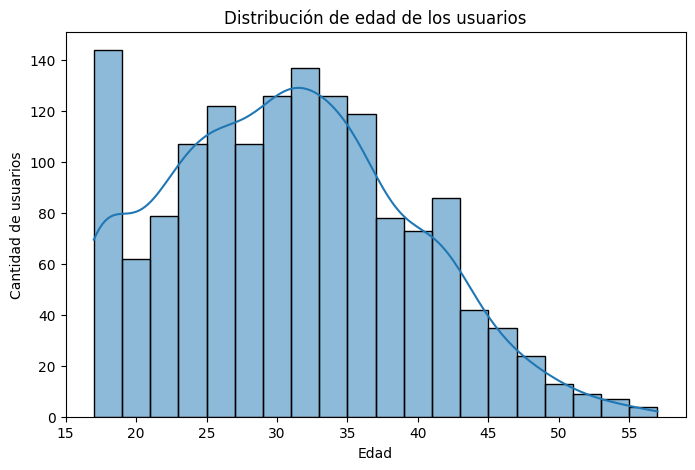

In [149]:
plt.figure(figsize=(8,5))
sns.histplot(data=content_data_clean, x="age", bins=20, kde=True)
plt.title("Distribución de edad de los usuarios")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

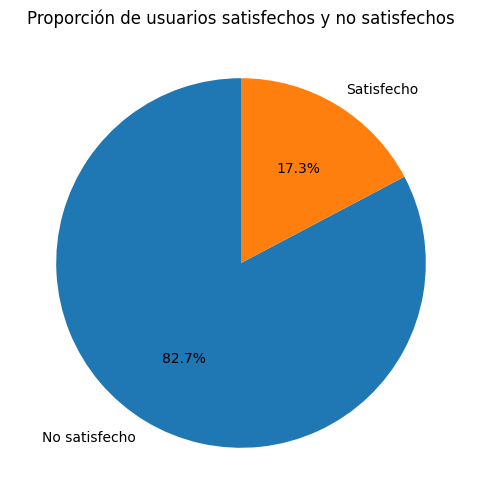

In [150]:
satisfied_counts = content_data_clean["satisfied"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    satisfied_counts,
    labels=["No satisfecho", "Satisfecho"],
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Proporción de usuarios satisfechos y no satisfechos")
plt.show()

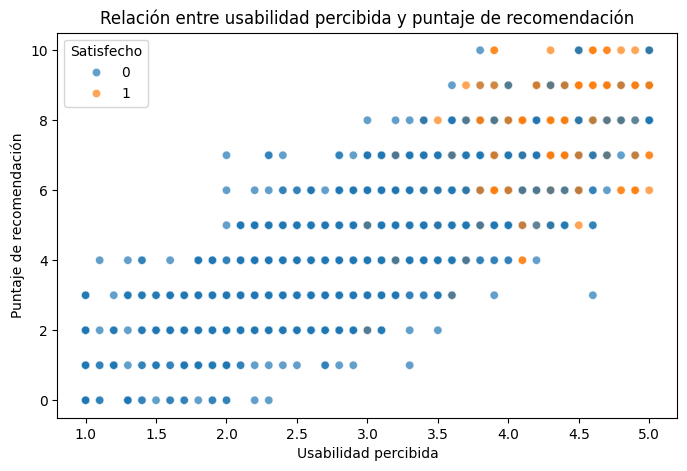

In [151]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=content_data_clean,
    x="perceived_usability",
    y="recommendation_score",
    hue="satisfied",
    alpha=0.7
)
plt.title("Relación entre usabilidad percibida y puntaje de recomendación")
plt.xlabel("Usabilidad percibida")
plt.ylabel("Puntaje de recomendación")
plt.legend(title="Satisfecho")
plt.show()

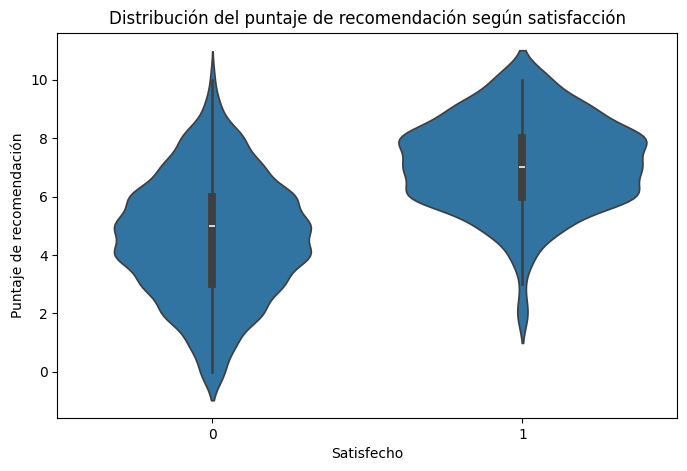

In [152]:
plt.figure(figsize=(8,5))
sns.violinplot(
    data=content_data_clean,
    x="satisfied",
    y="recommendation_score"
)
plt.title("Distribución del puntaje de recomendación según satisfacción")
plt.xlabel("Satisfecho")
plt.ylabel("Puntaje de recomendación")
plt.show()

# Machine Learning básico

In [133]:
#Separar variable objetivo y predictoras
target = "satisfied"

features = [
    "age",
    "gender",
    "city",
    "user_type",
    "device_type",
    "internet_quality",
    "sessions_per_week",
    "avg_session_minutes",
    "completed_activities",
    "pending_activities",
    "support_tickets",
    "response_time_hours",
    "platform_errors",
    "training_received",
    "support_channel",
    "platform_module",
    "perceived_usability",
    "recommendation_score"
]

X = content_data_clean[features]
y = content_data_clean[target]

In [134]:
#Separar variables numéricas y categóricas

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features

(['age',
  'sessions_per_week',
  'avg_session_minutes',
  'completed_activities',
  'pending_activities',
  'support_tickets',
  'response_time_hours',
  'platform_errors',
  'perceived_usability',
  'recommendation_score'],
 ['gender',
  'city',
  'user_type',
  'device_type',
  'internet_quality',
  'training_received',
  'support_channel',
  'platform_module'])

In [135]:
#Train/Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [136]:
#Pipeline del modelo

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(max_depth=5, random_state=42))
])

In [137]:
#Entrenar

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'city',
                                                   'user_type', 'device_type',
                                                   'internet_quality',
                                                   'training_received',
                                                   'support_channel',
                                                   'platform_module'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, random_state=42))])

In [142]:
#Predecir

y_pred = model.predict(X_test)

# Evaluación del modelo

En esta sección se evalúa el desempeño del modelo de clasificación entrenado. Para ello se utilizan métricas como accuracy, precision, recall y F1-score, además de la matriz de confusión. Estas métricas permiten analizar qué tan bien el modelo identifica usuarios satisfechos y no satisfechos.

In [143]:
# Métricas principales del modelo
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metricas_modelo = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Valor": [accuracy, precision, recall, f1]
})

metricas_modelo

,Métrica,Valor
0,Accuracy,0.853333
1,Precision,0.611111
2,Recall,0.423077
3,F1-score,0.500000


In [144]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91       248
           1       0.61      0.42      0.50        52

    accuracy                           0.85       300
   macro avg       0.75      0.68      0.71       300
weighted avg       0.84      0.85      0.84       300



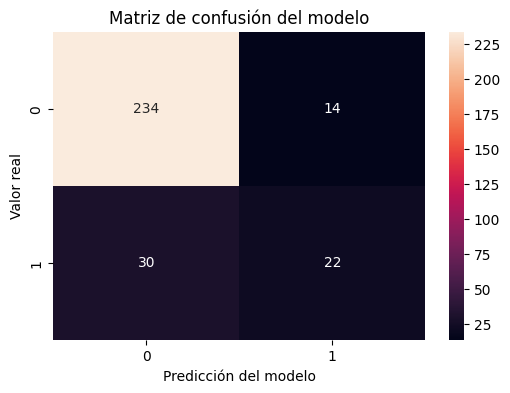

In [145]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de confusión del modelo")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.show()

La evaluación del modelo permite observar su capacidad para clasificar correctamente a los usuarios satisfechos y no satisfechos. El accuracy muestra la proporción total de predicciones correctas, mientras que precision indica qué tan confiables son las predicciones positivas del modelo. Recall permite conocer qué proporción de usuarios satisfechos reales fueron identificados correctamente, y F1-score resume el equilibrio entre precision y recall.

La matriz de confusión permite analizar los aciertos y errores del modelo, diferenciando los casos correctamente clasificados de los falsos positivos y falsos negativos.

In [146]:
# Obtener nombres de variables después del One-Hot Encoding
preprocessor_fitted = model.named_steps["preprocessor"]
classifier_fitted = model.named_steps["classifier"]

encoded_features = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_features = list(encoded_features) + numeric_features

feature_importance = pd.DataFrame({
    "Variable": all_features,
    "Importancia": classifier_fitted.feature_importances_
}).sort_values(by="Importancia", ascending=False)

feature_importance.head(15)

,Variable,Importancia
41,perceived_usability,0.671029
37,pending_activities,0.071453
11,user_type_Administrativo,0.047542
36,completed_activities,0.041838
35,avg_session_minutes,0.030682
42,recommendation_score,0.028584
39,response_time_hours,0.026705
0,gender_Femenino,0.013323
38,support_tickets,0.013000
34,sessions_per_week,0.012523


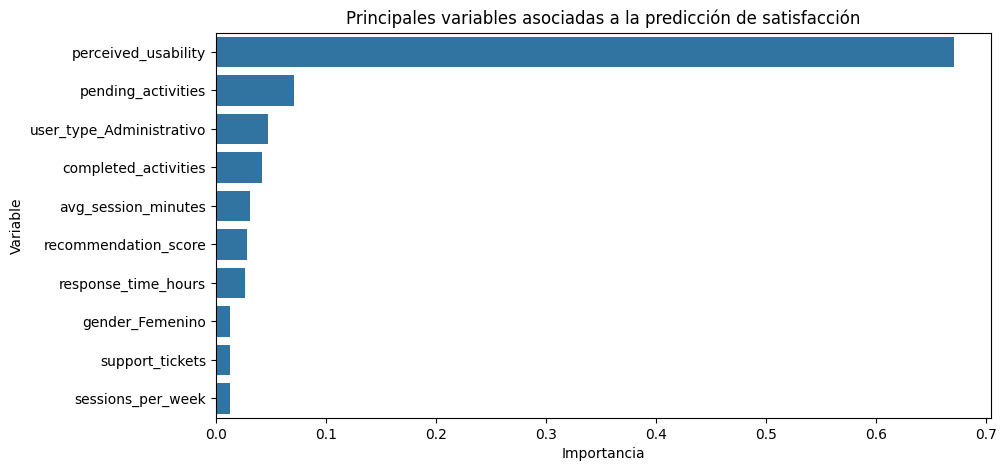

In [147]:
# Visualización de las variables más importantes
top_features = feature_importance.head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_features, x="Importancia", y="Variable")
plt.title("Principales variables asociadas a la predicción de satisfacción")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

El análisis de importancia de variables permite identificar qué características tuvieron mayor peso en la predicción de la satisfacción. Este resultado es útil para conectar el modelo de Machine Learning con la problemática analítica, ya que permite reconocer qué factores podrían influir más en la experiencia del usuario dentro de la plataforma digital educativa.

# Resultados y conclusiones

A partir del análisis exploratorio de datos se identificaron patrones relevantes asociados con la satisfacción de los usuarios de la plataforma digital educativa. Las variables relacionadas con la usabilidad percibida, la recomendación del servicio, la calidad de internet, la capacitación recibida, los errores reportados y el tiempo de respuesta del soporte permitieron comprender mejor la experiencia de los usuarios.

El proceso de limpieza permitió eliminar duplicados, tratar valores faltantes y preparar adecuadamente las variables para el análisis. Las variables categóricas fueron transformadas para poder ser utilizadas por el modelo de Machine Learning, mientras que las variables numéricas permitieron analizar diferencias entre usuarios satisfechos y no satisfechos.

El modelo de clasificación entrenado con DecisionTreeClassifier permitió predecir la variable objetivo satisfied. La evaluación mediante accuracy, precision, recall, F1-score y matriz de confusión permitió medir su desempeño y analizar sus principales aciertos y errores.

Como conclusión general, el análisis evidencia que la satisfacción del usuario en una plataforma digital no depende de un único factor, sino de la combinación entre experiencia de uso, estabilidad tecnológica, soporte recibido y nivel de interacción con el servicio. Este tipo de análisis puede apoyar la toma de decisiones orientada a mejorar la experiencia digital, priorizar acciones de capacitación, reducir errores de plataforma y optimizar los tiempos de atención.

In [148]:
# Resumen final de resultados principales
resumen_final = {
    "Registros finales luego de limpieza": content_data_clean.shape[0],
    "Columnas finales": content_data_clean.shape[1],
    "Porcentaje de usuarios satisfechos": round(content_data_clean["satisfied"].mean() * 100, 2),
    "Accuracy del modelo": round(accuracy * 100, 2),
    "Precision del modelo": round(precision * 100, 2),
    "Recall del modelo": round(recall * 100, 2),
    "F1-score del modelo": round(f1 * 100, 2)
}

pd.DataFrame(list(resumen_final.items()), columns=["Indicador", "Valor"])

,Indicador,Valor
0,Registros finales luego de limpieza,1500.00
1,Columnas finales,25.00
2,Porcentaje de usuarios satisfechos,17.27
3,Accuracy del modelo,85.33
4,Precision del modelo,61.11
5,Recall del modelo,42.31
6,F1-score del modelo,50.00



1. El dataset permitió aplicar un flujo completo de análisis
de datos en Python, incluyendo carga, revisión inicial, limpieza, transformación, análisis exploratorio, visualización y Machine Learning básico.

2. El análisis exploratorio mostró que variables como usabilidad percibida, recomendación, capacitación, calidad de internet, errores de plataforma y tiempos de respuesta tienen relación con la satisfacción del usuario.

3. El modelo de clasificación permitió predecir la variable satisfied a partir de variables demográficas, tecnológicas, operativas y de percepción.

4. El desempeño del modelo debe interpretarse como una aproximación académica inicial, ya que el dataset es sintético y fue construido con fines de aprendizaje.